# LAB 7b: Clustering Techniques (Gaussian Mixture Models - GMM)
**Mục tiêu:**
- Hiểu sự khác biệt giữa Soft Clustering (GMM) và Hard Clustering (K-Means).
- Nắm bắt thuật toán EM (Expectation-Maximization) đằng sau GMM.
- Ứng dụng GMM để xây dựng hệ thống Phát hiện bất thường (Anomaly Detection).
- So sánh phương pháp xác định bất thường bằng Mật độ xác suất (GMM) vs Khoảng cách hình học (K-Means).

In [1]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from scipy.spatial.distance import cdist

# Cài đặt giao diện
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## Bước 1: Tạo dữ liệu, EDA và Preprocessing
Chúng ta sẽ giả lập một hệ thống kiểm tra chất lượng sản phẩm (Manufacturing).
- **Dữ liệu bình thường (Normal):** Gồm 2 loại linh kiện tiêu chuẩn, phân bố theo hình Elip (có phương sai lệch).
- **Dữ liệu bất thường (Anomaly):** Các linh kiện bị lỗi, phân bố rải rác ngẫu nhiên.

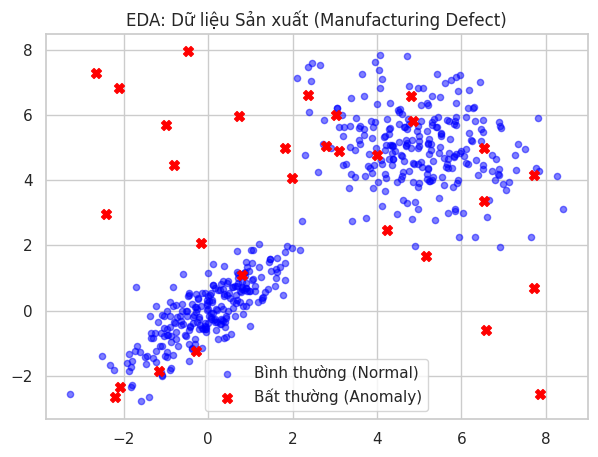

In [2]:
np.random.seed(42)

# 1. Tạo dữ liệu Bình thường (Normal) - Dùng 2 cụm hình Elip lệch
n_samples = 500
# Cụm 1
mean1 = [0, 0]
cov1 = [[1, 0.8], [0.8, 1]]
X_normal1 = np.random.multivariate_normal(mean1, cov1, n_samples // 2)
# Cụm 2
mean2 = [5, 5]
cov2 = [[1.5, -0.5], [-0.5, 1.5]]
X_normal2 = np.random.multivariate_normal(mean2, cov2, n_samples // 2)

X_normal = np.vstack((X_normal1, X_normal2))
y_normal = np.zeros(n_samples) # Nhãn 0: Bình thường

# 2. Tạo dữ liệu Lỗi (Anomaly) - Phân bố rải rác
n_anomalies = 30
X_anomaly = np.random.uniform(low=-3, high=8, size=(n_anomalies, 2))
y_anomaly = np.ones(n_anomalies) # Nhãn 1: Bất thường

# Gộp dữ liệu
X = np.vstack((X_normal, X_anomaly))
y_true = np.hstack((y_normal, y_anomaly))

# EDA: Trực quan hóa dữ liệu gốc
plt.figure(figsize=(7, 5))
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='blue', alpha=0.5, label='Bình thường (Normal)', s=20)
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', marker='X', s=50, label='Bất thường (Anomaly)')
plt.title('EDA: Dữ liệu Sản xuất (Manufacturing Defect)')
plt.legend()
plt.show()

## Bước 2, 3 & 4: Train GMM, Tính Log-Likelihood và Xác định Threshold
GMM sử dụng thuật toán **EM (Expectation-Maximization)**:
- **E-step:** Ước lượng xác suất mỗi điểm thuộc về cụm nào.
- **M-step:** Cập nhật lại các tham số $\mu$ (trung bình), $\Sigma$ (ma trận hiệp phương sai) để tối đa hóa xác suất.

Để tìm bất thường, ta tính **Log-Likelihood** (Mật độ xác suất logarit) cho từng điểm. Điểm nào có xác suất xuất hiện cực kỳ thấp (nằm ở rìa đồ thị) sẽ bị đánh dấu là Anomaly thông qua một ngưỡng `threshold` (Ví dụ: 4% dữ liệu thấp nhất).

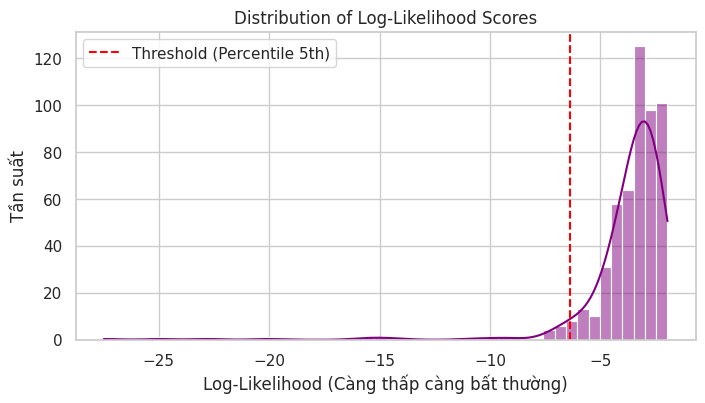

Ngưỡng Log-Likelihood xác định được: -6.3780


In [3]:
# 1. Train GMM CHỈ TRÊN DỮ LIỆU BÌNH THƯỜNG (Semi-supervised Anomaly Detection)
# Nếu trong thực tế không có nhãn sạch, ta train trên toàn bộ X, nhưng dùng subset Normal sẽ chuẩn hơn.
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_normal)

# 2. Tính Log-likelihood cho TOÀN BỘ dữ liệu X
# score_samples trả về giá trị log(p(x)), giá trị càng ÂM thì điểm đó càng hiếm/bất thường
log_probs = gmm.score_samples(X)

# 3. Trực quan hóa Phân bố Log-likelihood
plt.figure(figsize=(8, 4))
sns.histplot(log_probs, bins=50, kde=True, color='purple')
plt.title('Distribution of Log-Likelihood Scores')
plt.xlabel('Log-Likelihood (Càng thấp càng bất thường)')
plt.ylabel('Tần suất')

# 4. Xác định Threshold (Ngưỡng) thủ công bằng Percentile
# Giả sử ta biết tỷ lệ lỗi trong nhà máy là khoảng ~5%
contamination_rate = 5
threshold = np.percentile(log_probs, contamination_rate)

plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold (Percentile {contamination_rate}th)')
plt.legend()
plt.show()

print(f"Ngưỡng Log-Likelihood xác định được: {threshold:.4f}")

## Bước 5 & 6: Đánh dấu Anomaly và Đánh giá (Evaluation)
Bất kỳ điểm dữ liệu nào có $p(x) < \text{threshold}$ sẽ bị mô hình dự đoán là 1 (Lỗi/Anomaly). Sau đó, ta dùng Confusion Matrix và các chỉ số (Precision, Recall, F1) để đo lường.

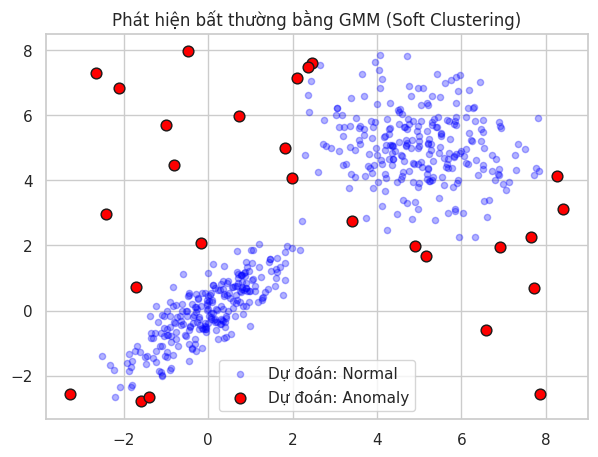

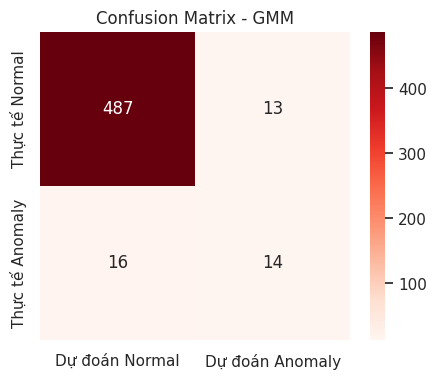

In [4]:
# 1. Gán nhãn dự đoán (1: Anomaly, 0: Normal)
y_pred_gmm = (log_probs < threshold).astype(int)

# 2. Trực quan hóa kết quả dự đoán của GMM
plt.figure(figsize=(7, 5))
plt.scatter(X[y_pred_gmm == 0, 0], X[y_pred_gmm == 0, 1], c='blue', alpha=0.3, label='Dự đoán: Normal', s=20)
plt.scatter(X[y_pred_gmm == 1, 0], X[y_pred_gmm == 1, 1], c='red', marker='o', edgecolors='k', s=60, label='Dự đoán: Anomaly')
plt.title('Phát hiện bất thường bằng GMM (Soft Clustering)')
plt.legend()
plt.show()

# 3. Đánh giá mô hình
cm_gmm = confusion_matrix(y_true, y_pred_gmm)
prec_gmm = precision_score(y_true, y_pred_gmm)
rec_gmm = recall_score(y_true, y_pred_gmm)
f1_gmm = f1_score(y_true, y_pred_gmm)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Dự đoán Normal', 'Dự đoán Anomaly'],
            yticklabels=['Thực tế Normal', 'Thực tế Anomaly'])
ax.set_title('Confusion Matrix - GMM')
plt.show()

## Bước 7: So sánh GMM vs K-Means
Để dùng K-Means cho Anomaly Detection, ta tính khoảng cách từ mỗi điểm đến tâm cụm gần nhất của nó. Những điểm nằm cách xa tâm cụm nhất sẽ bị coi là bất thường.
*Nhược điểm của K-Means:* Khoảng cách là hình cầu (Hard shape), nó không hiểu được sự "kéo dài" hoặc mật độ của dữ liệu hình Elip như GMM.

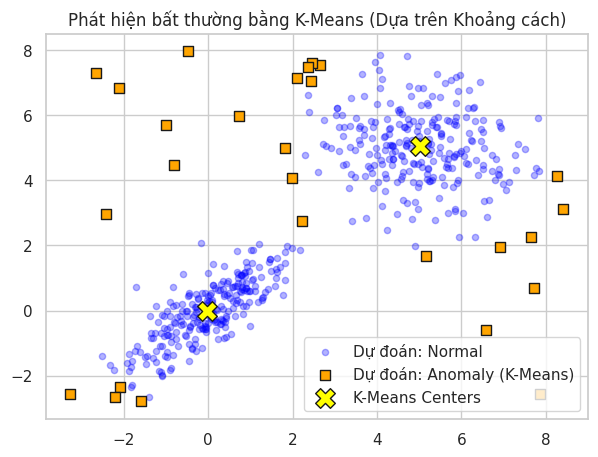

--- BẢNG SO SÁNH HIỆU QUẢ PHÁT HIỆN LỖI ---


,Metric,GMM (Density-based),K-Means (Distance-based)
0,Precision,0.5185,0.5556
1,Recall,0.4667,0.5000
2,F1-Score,0.4912,0.5263


In [5]:
# 1. Train K-Means trên dữ liệu Normal
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_normal)

# 2. Tính khoảng cách từ mọi điểm đến tâm cụm gần nhất
distances = np.min(cdist(X, kmeans.cluster_centers_), axis=1)

# 3. Đặt Threshold cho K-Means (Lấy top 5% điểm xa nhất làm Anomaly)
threshold_kmeans = np.percentile(distances, 100 - contamination_rate)
y_pred_kmeans = (distances > threshold_kmeans).astype(int)

# 4. Trực quan hóa kết quả của K-Means
plt.figure(figsize=(7, 5))
plt.scatter(X[y_pred_kmeans == 0, 0], X[y_pred_kmeans == 0, 1], c='blue', alpha=0.3, label='Dự đoán: Normal', s=20)
plt.scatter(X[y_pred_kmeans == 1, 0], X[y_pred_kmeans == 1, 1], c='orange', marker='s', edgecolors='k', s=50, label='Dự đoán: Anomaly (K-Means)')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='yellow', marker='X', s=200, edgecolors='k', label='K-Means Centers')
plt.title('Phát hiện bất thường bằng K-Means (Dựa trên Khoảng cách)')
plt.legend()
plt.show()

# 5. Đánh giá và So sánh
prec_km = precision_score(y_true, y_pred_kmeans)
rec_km = recall_score(y_true, y_pred_kmeans)
f1_km = f1_score(y_true, y_pred_kmeans)

comparison_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'GMM (Density-based)': [prec_gmm, rec_gmm, f1_gmm],
    'K-Means (Distance-based)': [prec_km, rec_km, f1_km]
})

print("--- BẢNG SO SÁNH HIỆU QUẢ PHÁT HIỆN LỖI ---")
display(comparison_df.round(4))